## 🚧 Borders & Obstacles

**Concepts:** [Crossings & detours](../problem.md#crossings-contours-and-detours)

**OptiWindNet** models site bounds with an exterior **border** (allowed area) and interior **obstacles** (exclusion zones), and keeps electrical network design compliant with the bounds. This notebook walks from initialization and optimization under constraints, through cleaning and buffering the geometry, to validating turbine and substation placement. It explores the following methods:

- **Optimize under bounds**: [.optimize()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.optimize): optimize electrical network while enforcing border/obstacle constraints.
- **Merge & clean boundary**: [.merge_obstacles_into_border()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.merge_obstacles_into_border): resolve intersections/touching constraints, absorb irrelevant obstacles, and simplify the exterior boundary.
- **Buffer geometry**: [.add_buffer()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.add_buffer): expand the border and shrink obstacles to add safety margins; this may smooth concavities or remove obstacles depending on `buffer_dist`.
- **Compare originals vs buffered**: [.plot_original_vs_buffered()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.plot_original_vs_buffered): overlay plot of border/obstacles before and after buffering to inspect how buffering changed shapes.
- **Validate turbine placement**: [.optimize()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.optimize) raises a `ValueError` if any turbine lies outside the border or inside an obstacle. Substations are not subject to this placement check and may lie outside the border.

Import required packages

In [1]:
import numpy as np

from optiwindnet.api import WindFarmNetwork

In [2]:
# Display figures as SVG in Jupyter notebooks
%config InlineBackend.figure_formats = ['svg']

### Borders and obstacles

#### 1. Initialize

Create a [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) instance from an `.osm.pbf` file and optimize it.

In [3]:
wfn1 = WindFarmNetwork.from_pbf(filepath='data/DTU_letters.osm.pbf', cables=7)

Plot the location geometry and the optimized network to confirm that the borders and obstacles are properly initialized and considered for optimization.

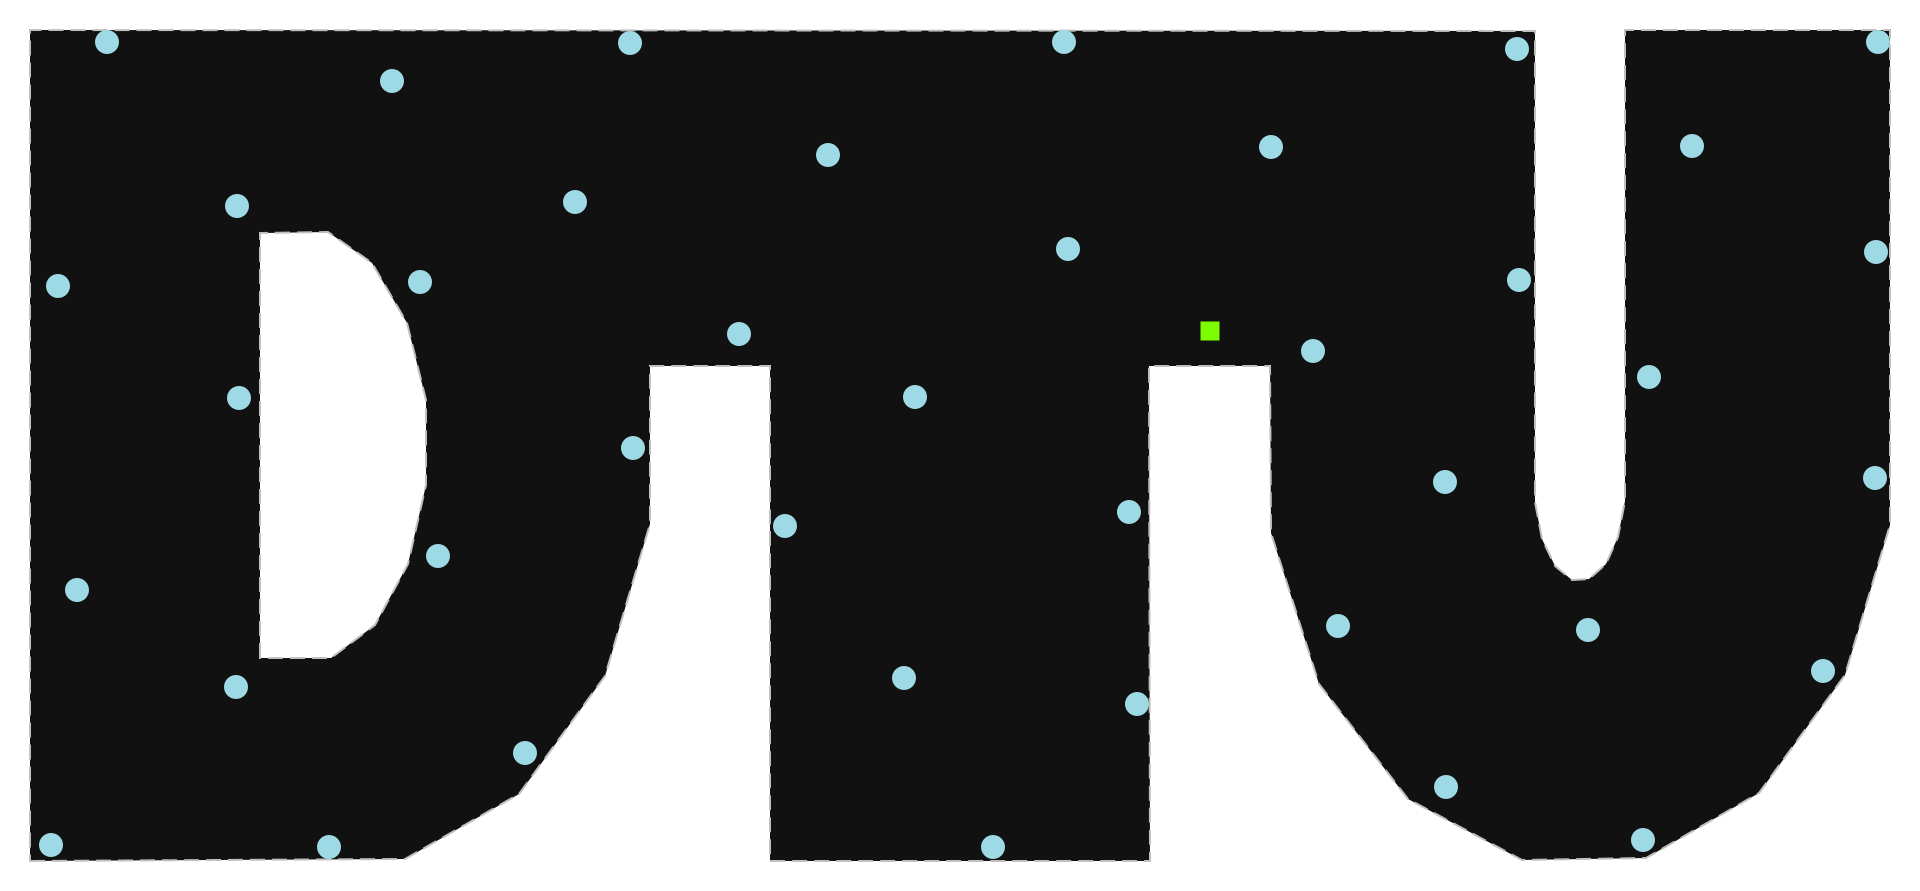

In [4]:
wfn1

In [5]:
wfn1.L.graph['T']

40

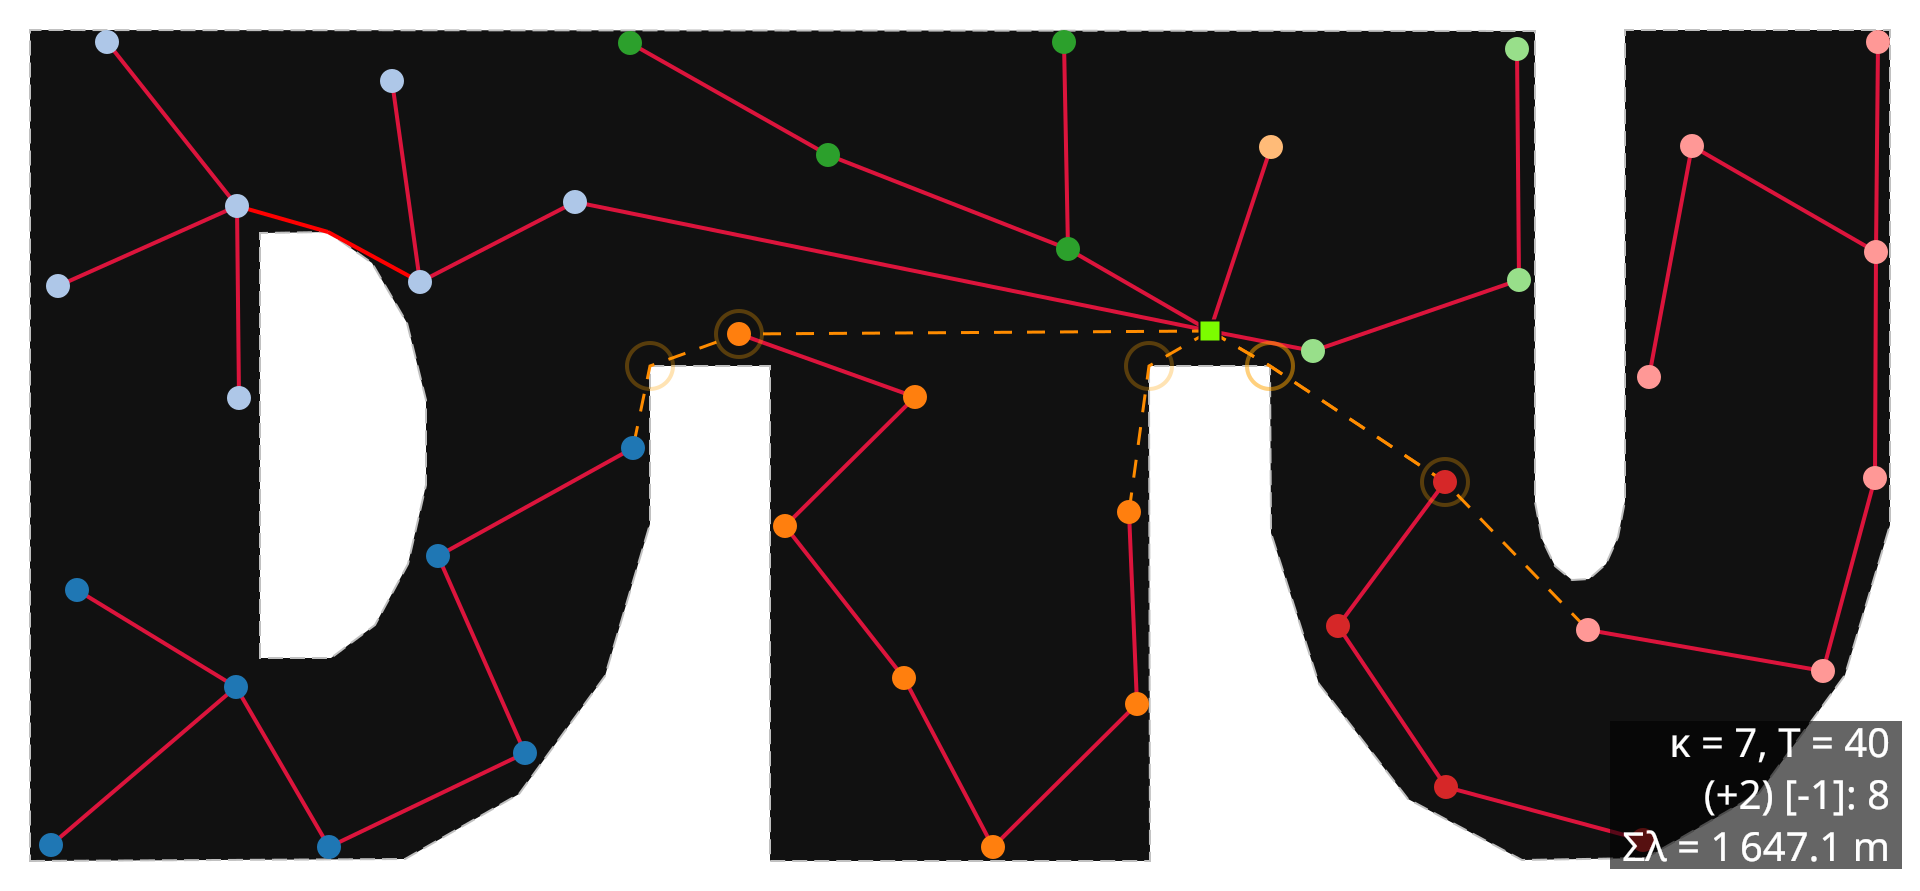

In [6]:
res_optimize = wfn1.optimize()
wfn1

In [7]:
wfn1.solution_info()

{'router': 'EWRouter', 'capacity': 7, 'method': 'biased_EW', 'iterations': 37}

> Note: OptiWindNet also works without a border or obstacles.

#### 2. Obstacles intersecting with the exterior borders

Create a [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) directly from coordinates to define its border and obstacles explicitly.

In [8]:
turbinesC = np.array([
    [316976, 6175410], [316998, 6175380], [316965, 6175368],
    [316997, 6175347], [316967, 6175314], [317009, 6175267],
    [317044, 6175282], [316994, 6175296], [317065, 6175335],
    [317030, 6175318], [317029, 6175366], [317026, 6175401],
    [317057, 6175379], [317085, 6175354], [317068, 6175406],
    [317144, 6175403], [317115, 6175342], [317091, 6175320],
    [317240, 6175259], [317111, 6175293], [317126, 6175262],
    [317152, 6175320], [317102, 6175385], [317179, 6175383],
    [317143, 6175367], [317223, 6175399], [317222, 6175358],
    [317185, 6175347], [317208, 6175323], [317188, 6175299],
    [317205, 6175270], [317231, 6175296], [317272, 6175287],
    [317244, 6175340], [317283, 6175321], [317285, 6175360],
    [316960, 6175270], [317253, 6175380], [317287, 6175397],
    [317152, 6175286],
])  # fmt: skip

borderC = np.array([
    [316956, 6175267], [317022, 6175265], [317043, 6175275],
    [317059, 6175295], [317068, 6175322], [317069, 6175349],
    [317090, 6175348], [317086, 6175262], [317153, 6175259],
    [317157, 6175346], [317178, 6175345], [317177, 6175316],
    [317184, 6175289], [317199, 6175268], [317218, 6175256],
    [317240, 6175256], [317260, 6175266], [317276, 6175286],
    [317285, 6175312], [317289, 6175399], [317242, 6175401],
    [317239, 6175319], [317238, 6175312], [317235, 6175308],
    [317232, 6175305], [317229, 6175305], [317226, 6175308],
    [317224, 6175313], [317223, 6175319], [317227, 6175402],
    [316963, 6175413],
])  # fmt: skip

obstaclesC_ = [
    np.array([
        [316998, 6175301], [317001, 6175376], [317013, 6175375],
        [317021, 6175369], [317026, 6175359], [317029, 6175345],
        [317029, 6175330], [317025, 6175316], [317019, 6175306],
        [317011, 6175301],
    ]),
    np.array([
        [316920, 6175300], [316920, 6175400], [316950, 6175400],
        [316950, 6175300],
    ]),
    np.array([
        [317100, 6175450], [317100, 6175400], [317080, 6175400],
        [317080, 6175450],
    ]),
]  # fmt: skip

substationsC = np.array([[317167, 6175351]])

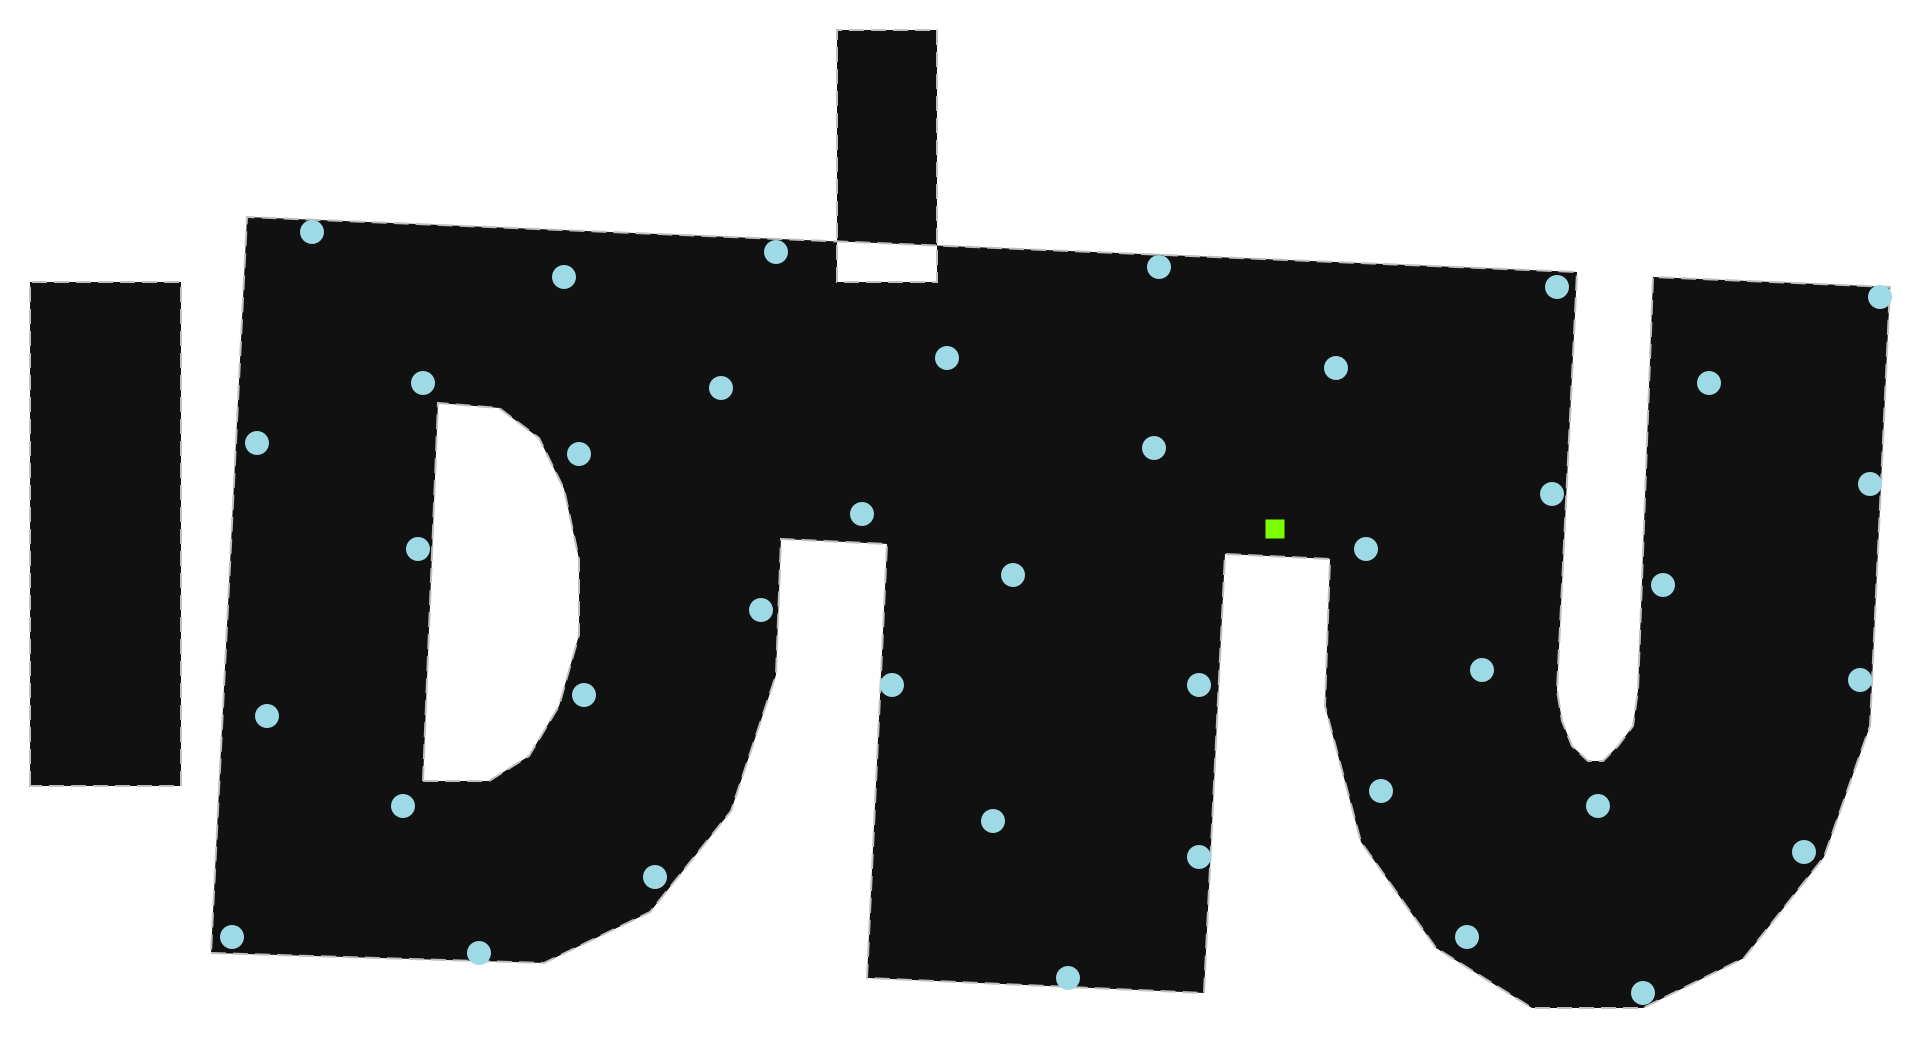

In [9]:
wfn2 = WindFarmNetwork(
    turbinesC=turbinesC,
    substationsC=substationsC,
    borderC=borderC,
    obstacleC_=obstaclesC_,
    cables=7,
)
wfn2

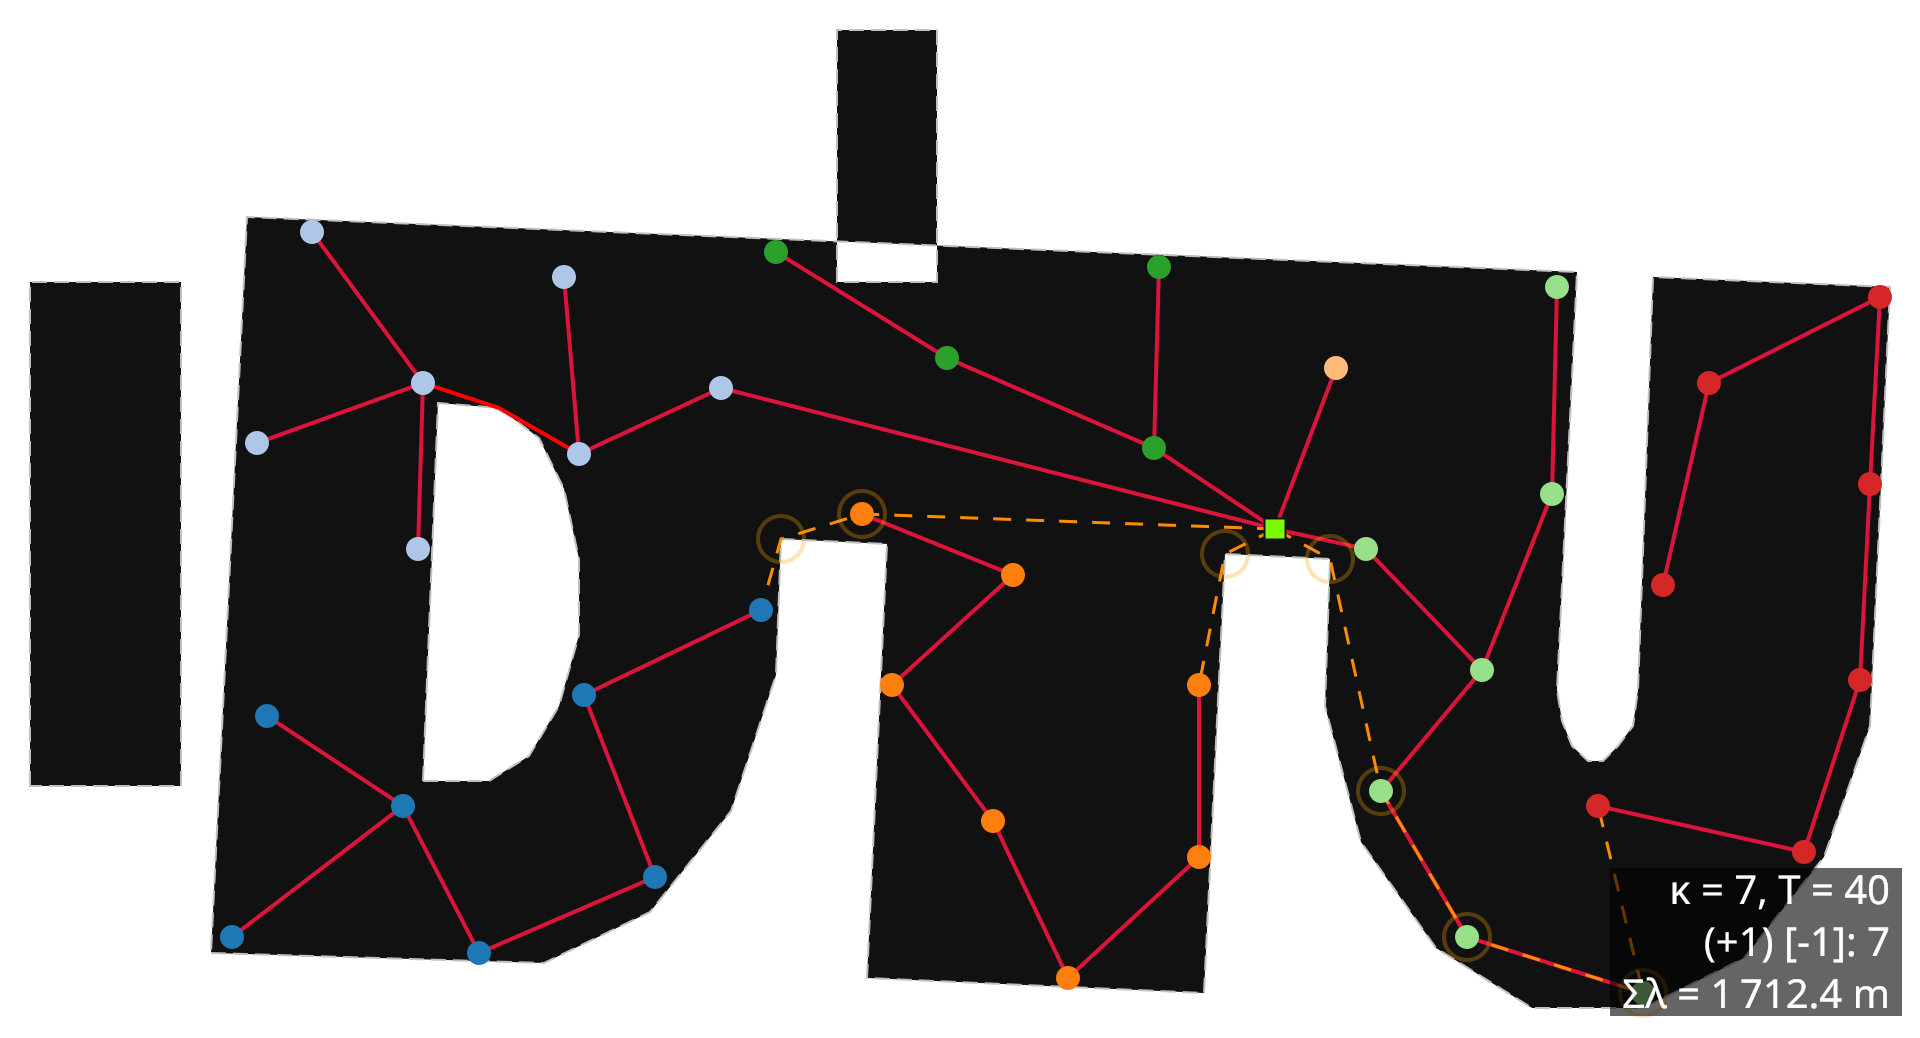

In [10]:
res_optimize = wfn2.optimize()
wfn2

In [11]:
wfn2.solution_info()

{'router': 'EWRouter', 'capacity': 7, 'method': 'biased_EW', 'iterations': 35}

Use [.merge_obstacles_into_border()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.merge_obstacles_into_border) to refine the border, simplify the boundary constraints, and remove irrelevant obstacles.

Obstacle at index 1 is completely outside the border and is neglected.
Obstacle at index 2 intersects with the exteriour border and is merged into the exterior border.


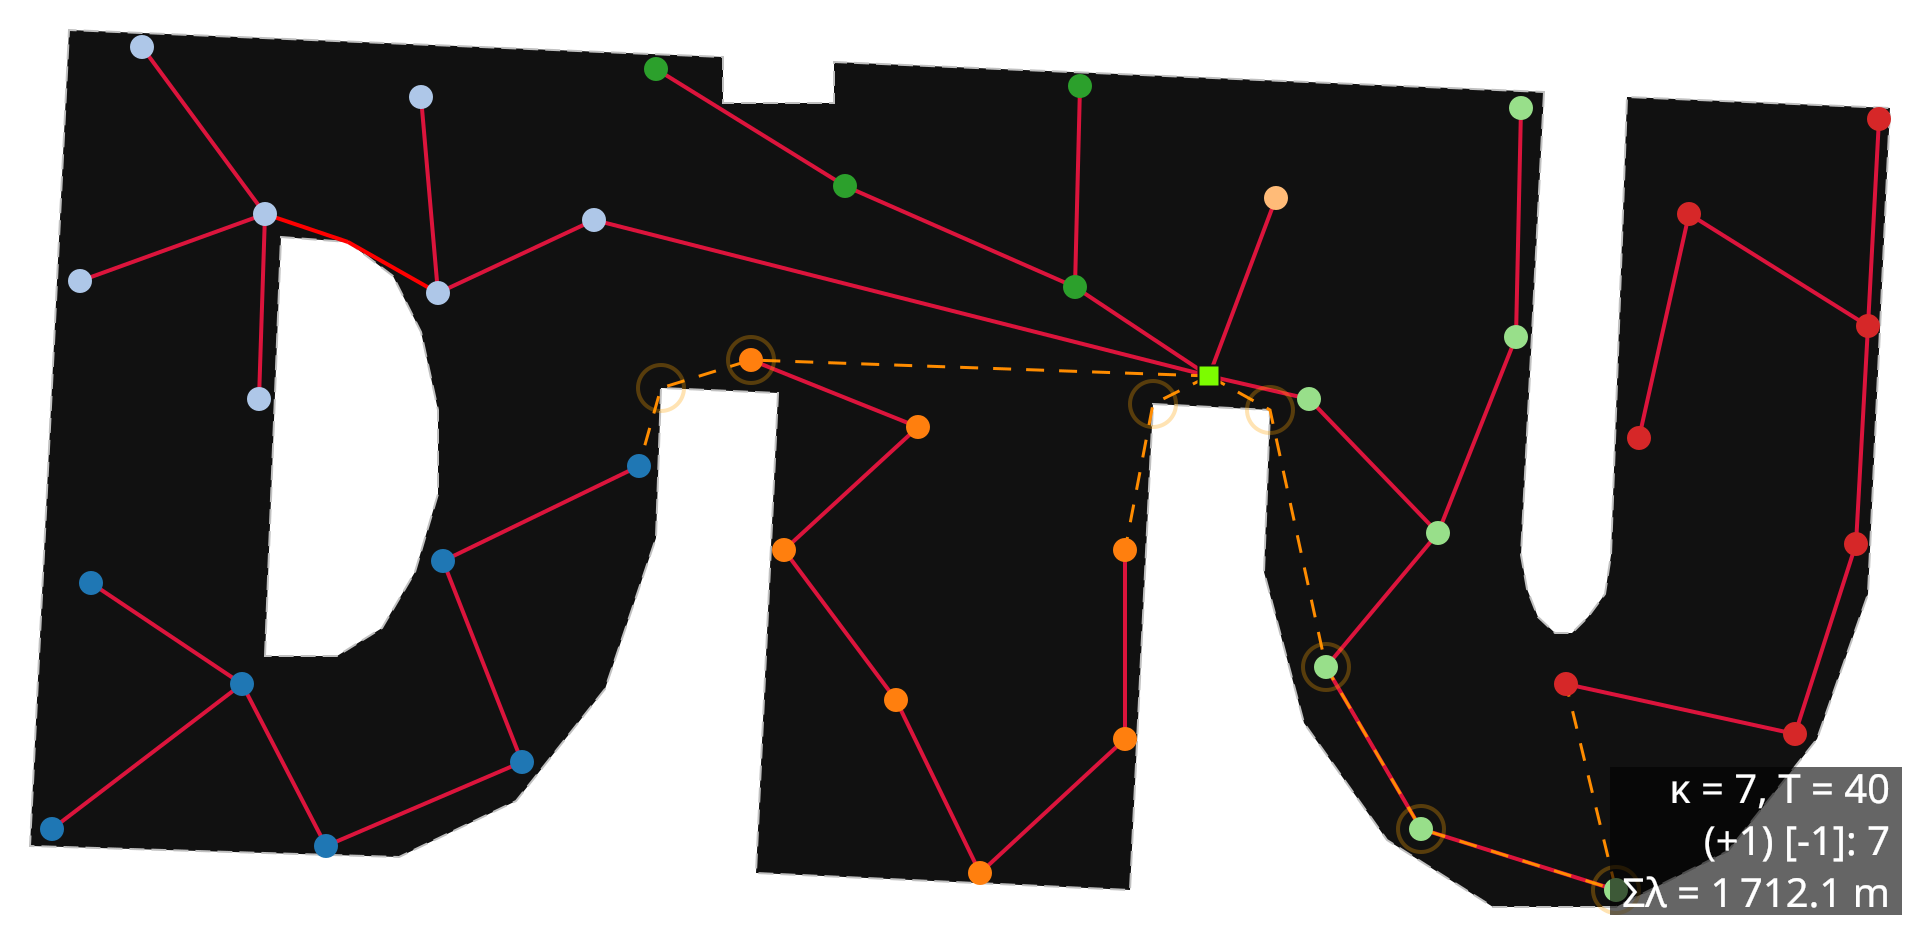

In [12]:
wfn2.merge_obstacles_into_border()
res_optimize = wfn2.optimize()
wfn2

In [13]:
wfn2.solution_info()

{'router': 'EWRouter', 'capacity': 7, 'method': 'biased_EW', 'iterations': 35}

### Buffering

Buffering expands the exterior border and shrinks the interior obstacles by a given distance, adding a safety margin between cables and boundaries. It is applied with [.add_buffer()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.add_buffer) after initialization. See [Preparing the geometry](../reference/input_formats.md#preparing-the-geometry) for what buffering can remove from a location and why.

Initialize [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) instance

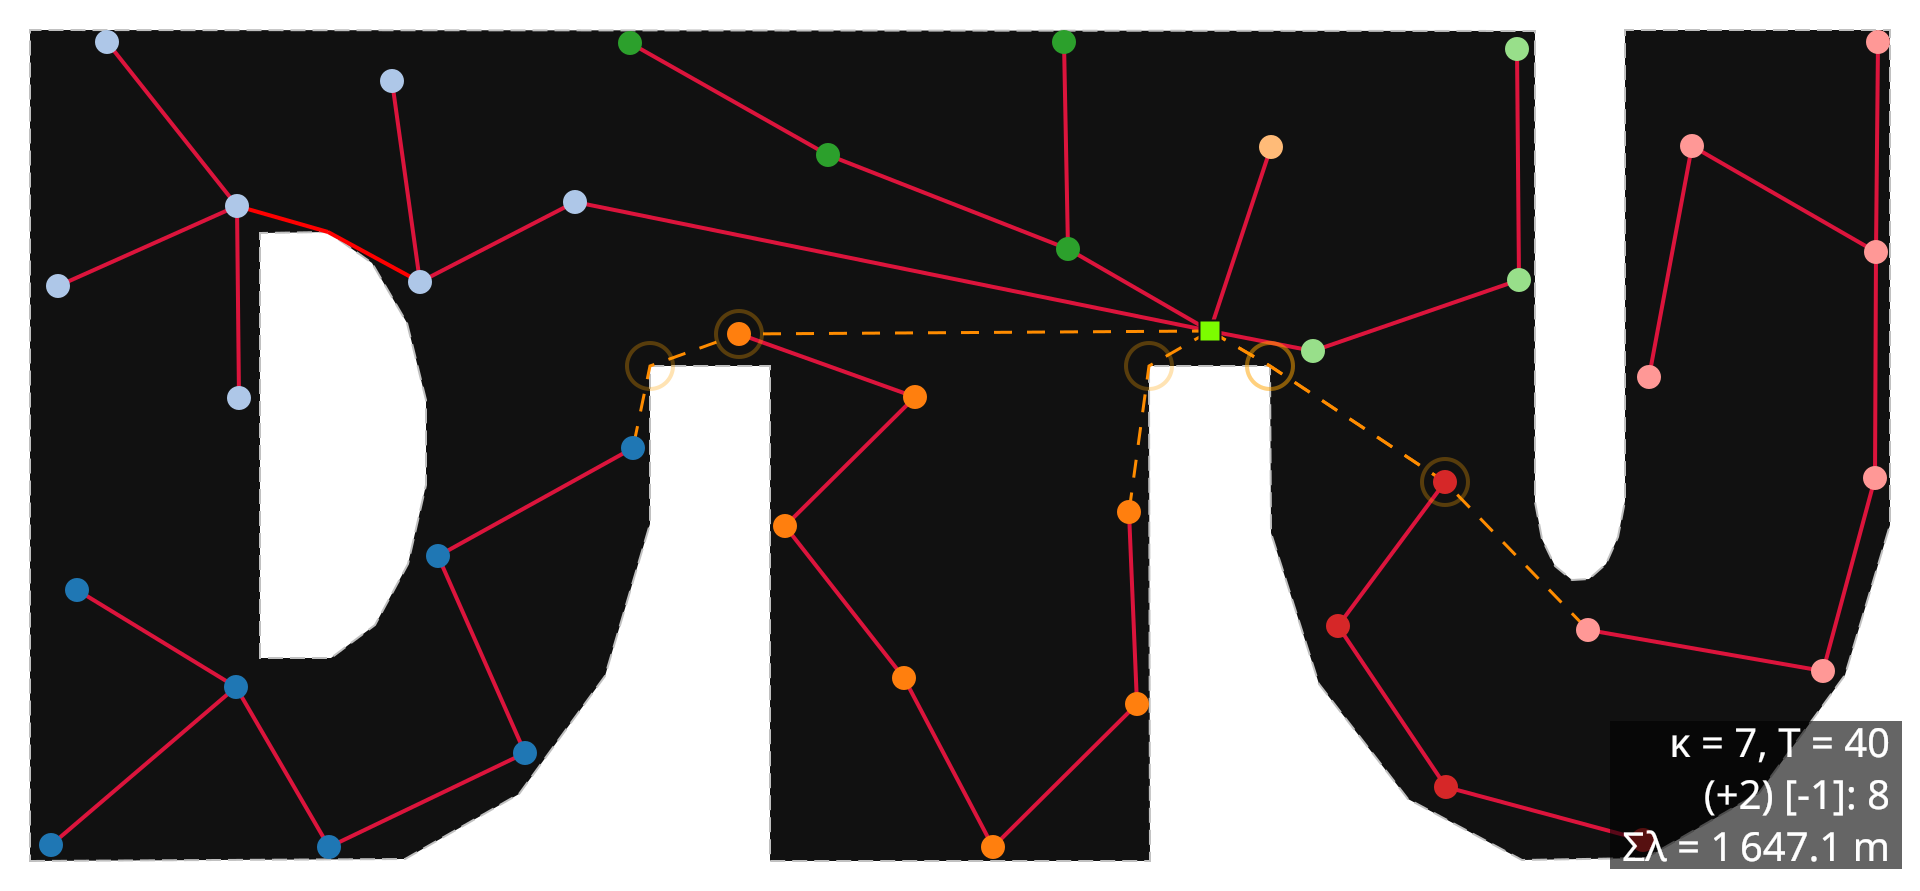

In [14]:
wfn3 = WindFarmNetwork.from_pbf(filepath='data/DTU_letters.osm.pbf', cables=7)
res_optimize = wfn3.optimize()
wfn3

In [15]:
wfn3.solution_info()

{'router': 'EWRouter', 'capacity': 7, 'method': 'biased_EW', 'iterations': 37}

Apply buffering to `wfn3`.

The defined border is non-convex and buffering may introduce unexpected changes. For visual comparison use plot_original_vs_buffered().


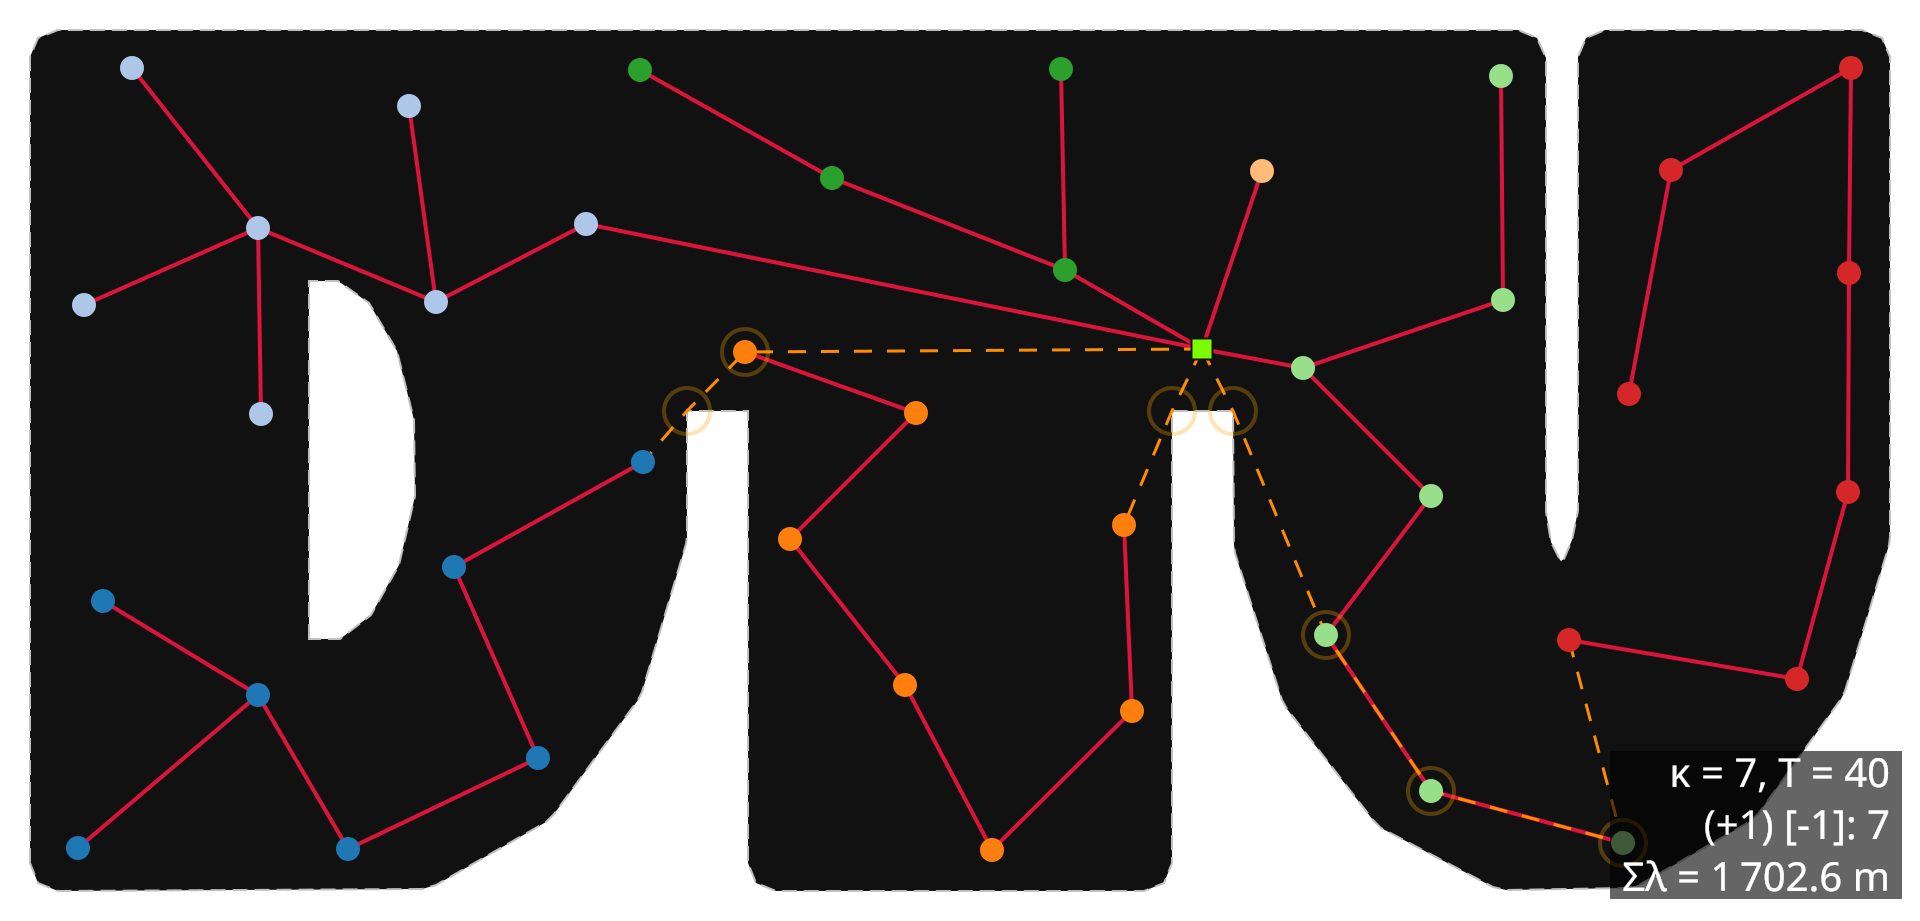

In [16]:
wfn3.add_buffer(buffer_dist=5)
res_optimize = wfn3.optimize()
wfn3

In [17]:
wfn3.solution_info()

{'router': 'EWRouter', 'capacity': 7, 'method': 'biased_EW', 'iterations': 35}

Visualize the original and buffered border and obstacles with [plot_original_vs_buffered()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.plot_original_vs_buffered).

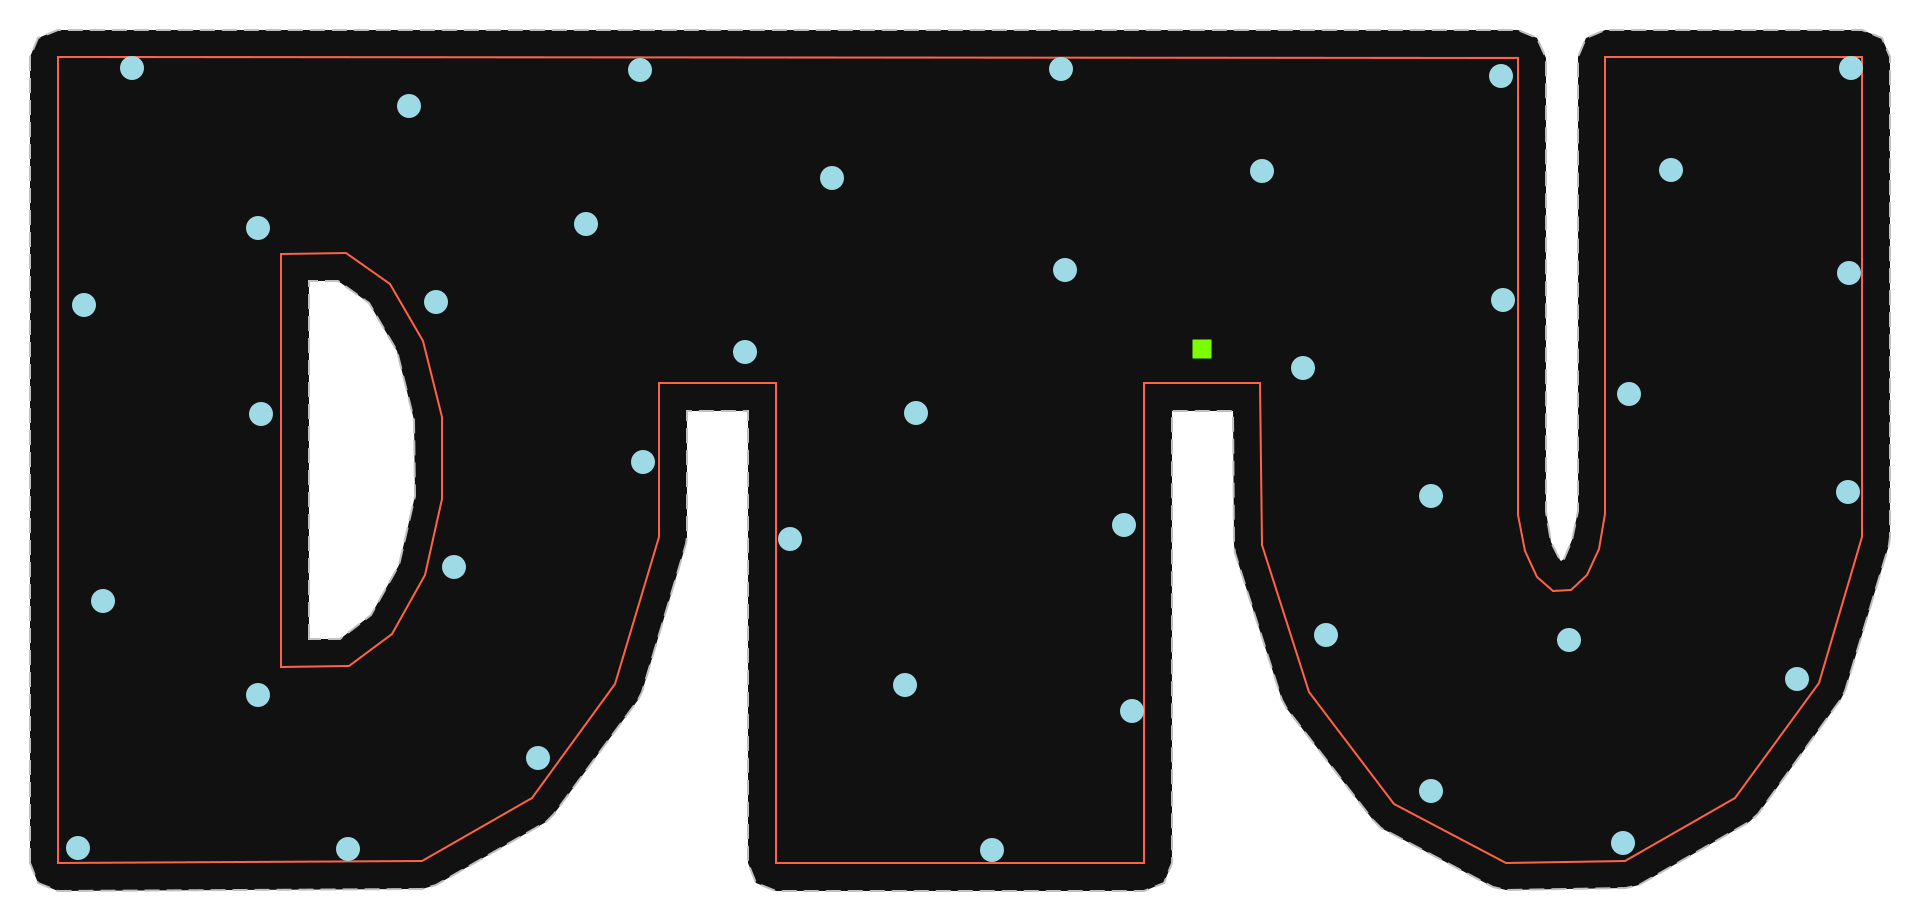

In [18]:
wfn3.plot_original_vs_buffered()

#### Removal of a concavity

In this case, a message describes the potential changes to the border.

In [19]:
wfn4 = WindFarmNetwork.from_pbf(filepath='data/DTU_letters.osm.pbf', cables=7)
wfn4.add_buffer(buffer_dist=10)

The defined border is non-convex and buffering may introduce unexpected changes. For visual comparison use plot_original_vs_buffered().


Plotting original vs buffered borders confirms that one of the concavities is removed after buffering.

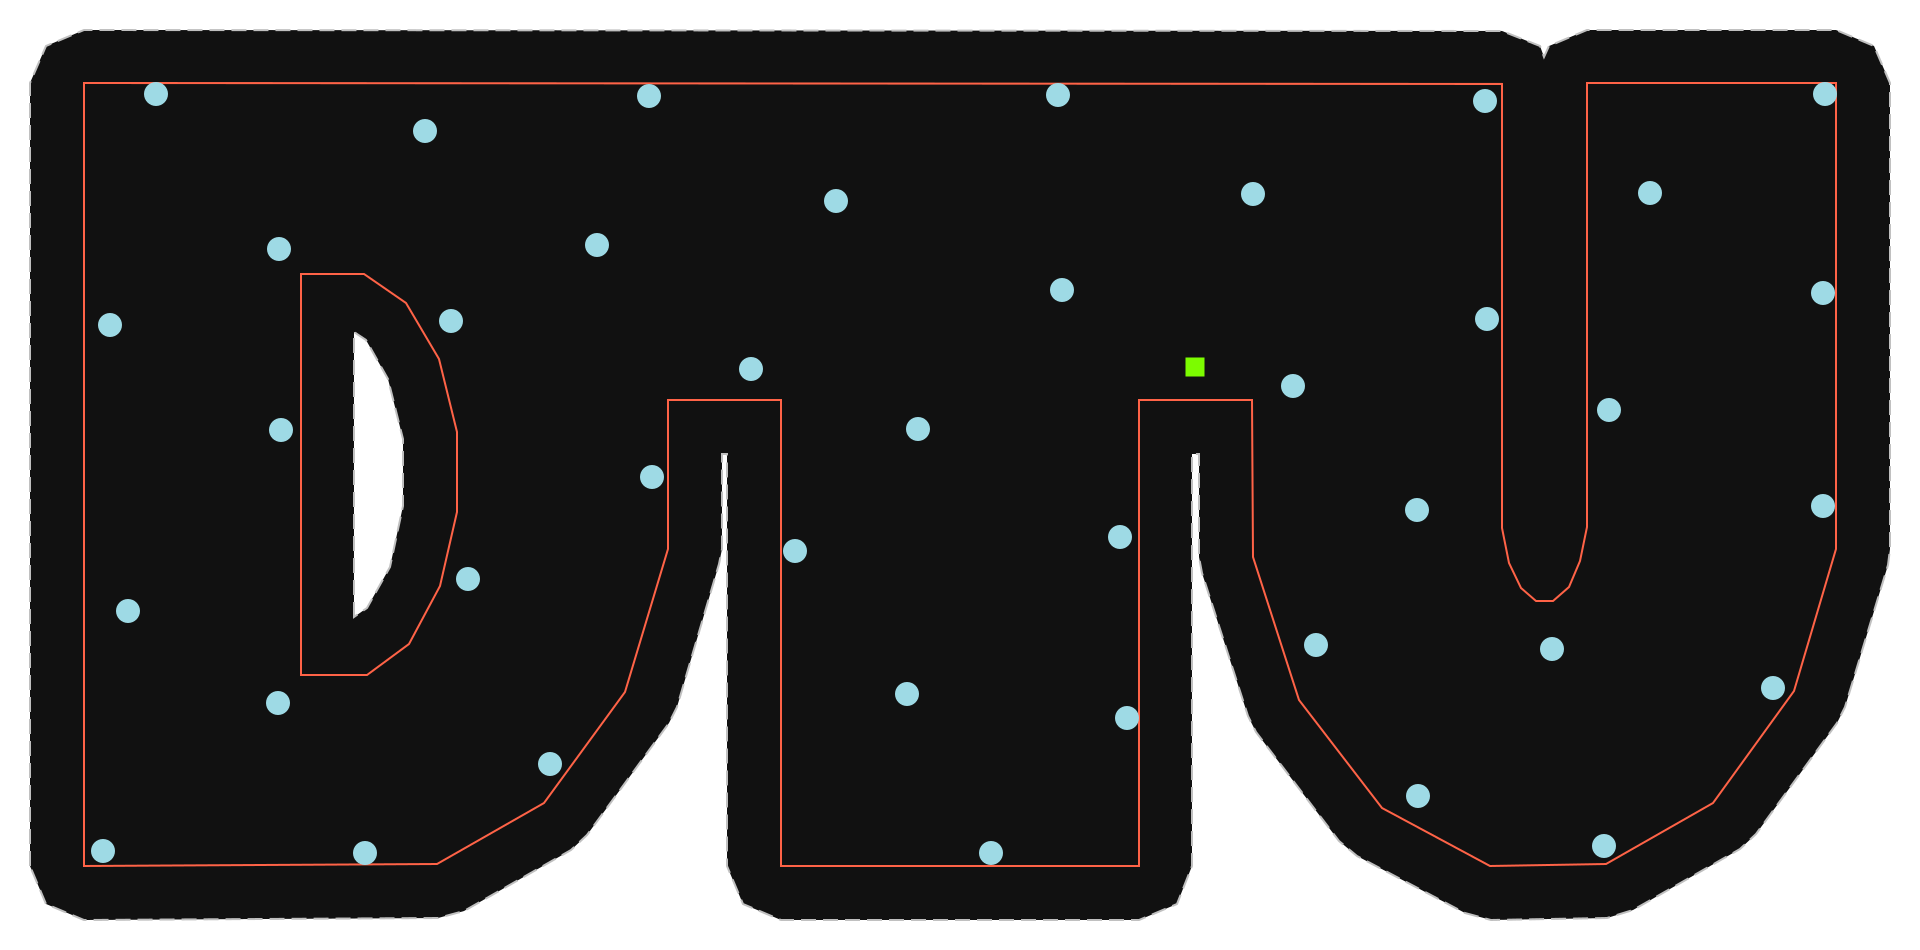

In [20]:
wfn4.plot_original_vs_buffered()

**Optimize**

The optimized network might change and use new routes after buffering.

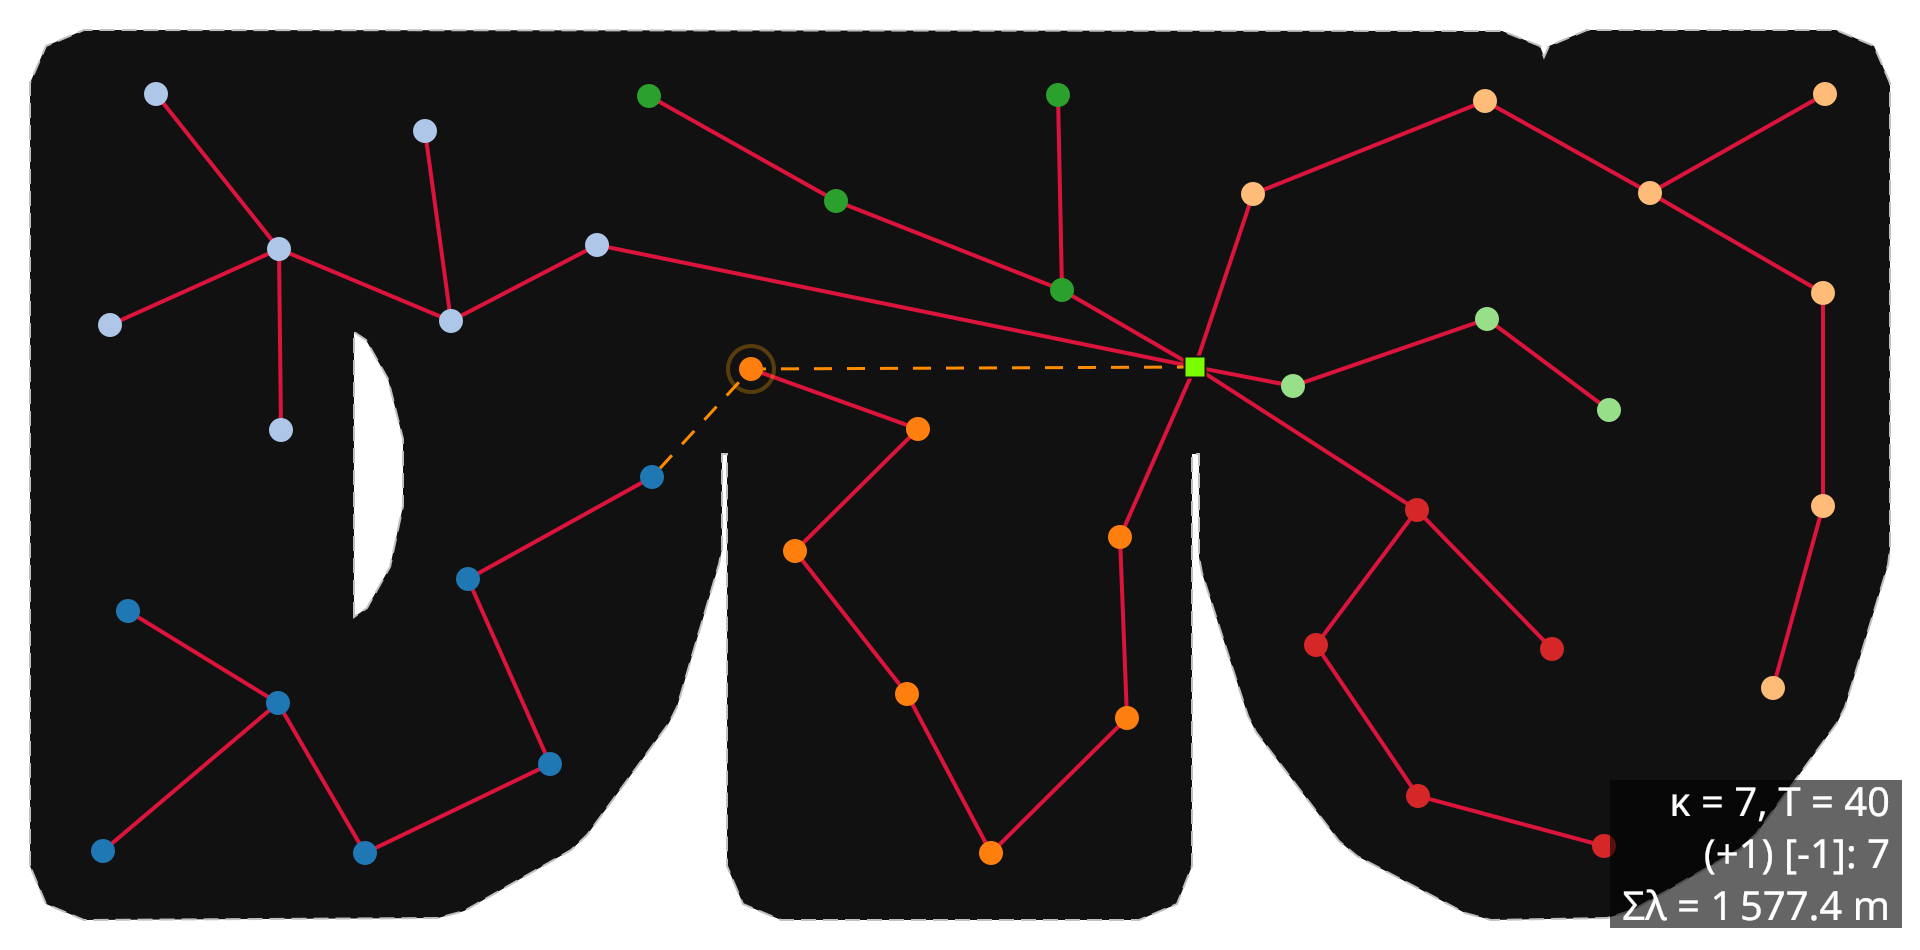

In [21]:
res_optimize = wfn4.optimize()
wfn4

In [22]:
wfn4.solution_info()

{'router': 'EWRouter', 'capacity': 7, 'method': 'biased_EW', 'iterations': 35}

#### Removal of an obstacle

In [23]:
wfn5 = WindFarmNetwork.from_pbf(filepath='data/DTU_letters.osm.pbf', cables=7)
wfn5.add_buffer(buffer_dist=15)

The defined border is non-convex and buffering may introduce unexpected changes. For visual comparison use plot_original_vs_buffered().
Buffering by 15.00 completely removed the obstacle at index 0. For visual comparison use plot_original_vs_buffered().


Plotting the original and buffered borders confirms that the obstacle inside the letter D is removed after buffering.

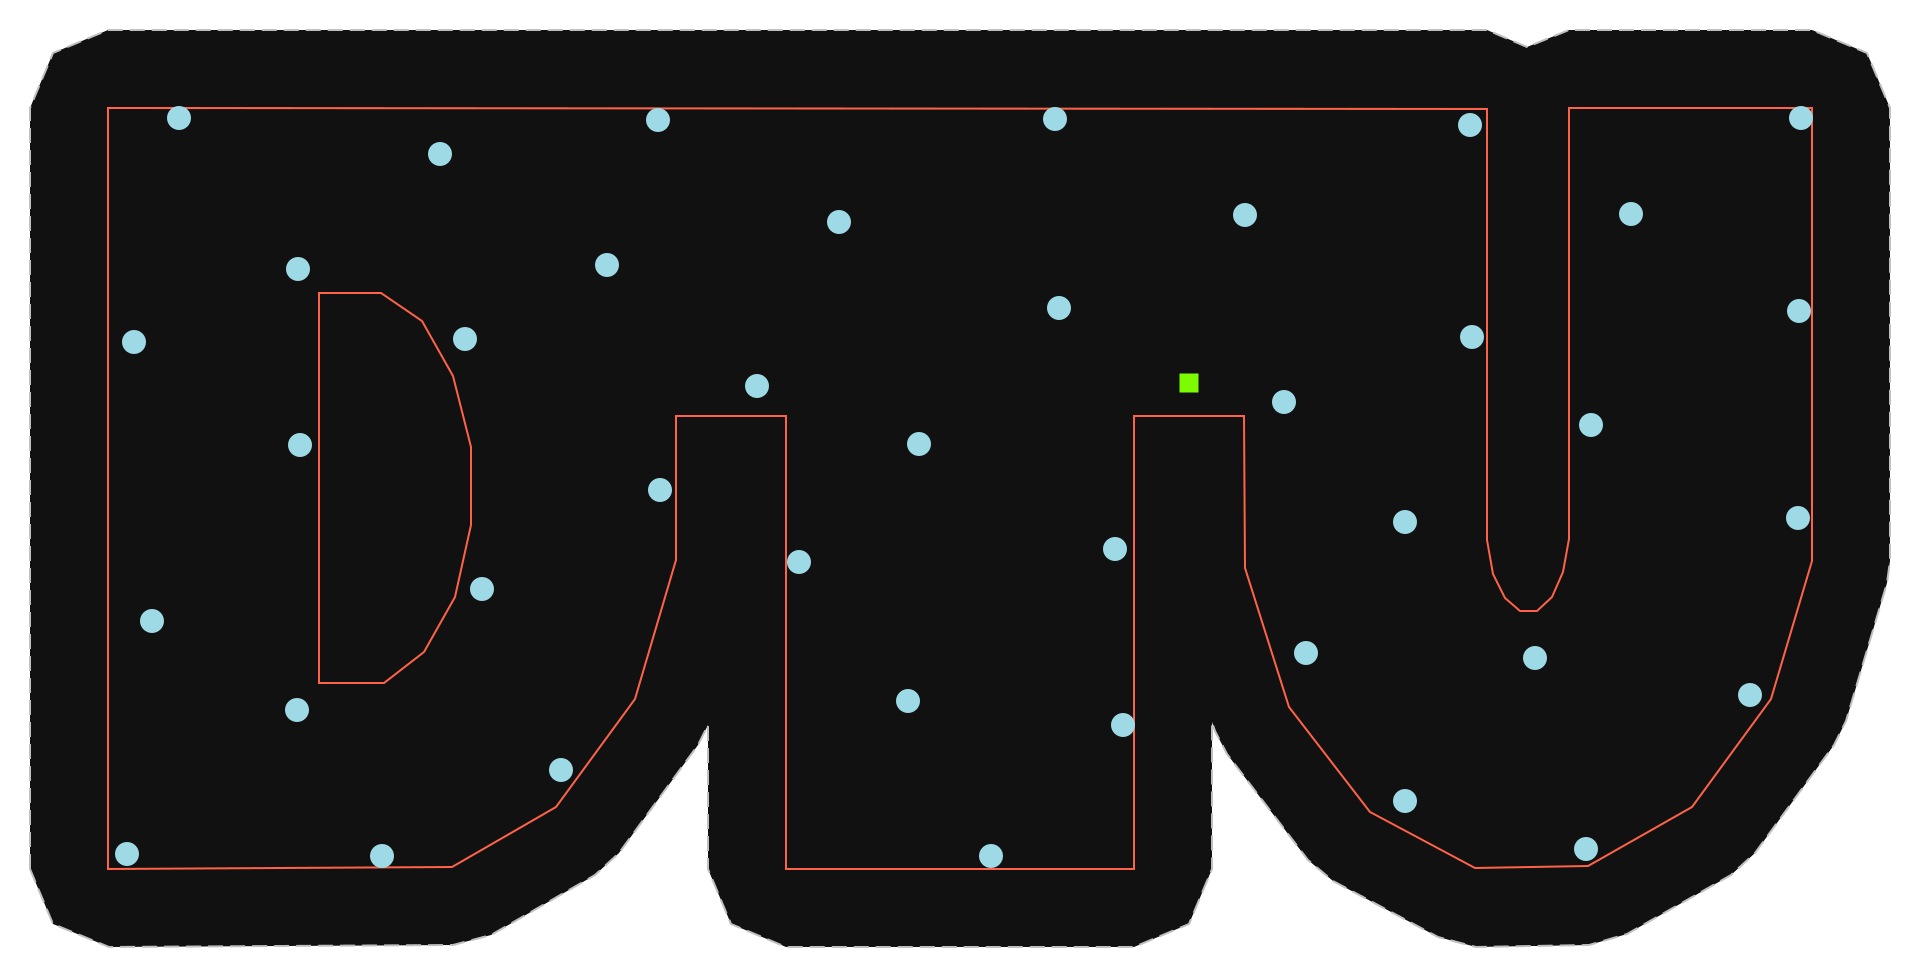

In [24]:
wfn5.plot_original_vs_buffered()

**Optimize**

The optimized network might change and use new routes after buffering.

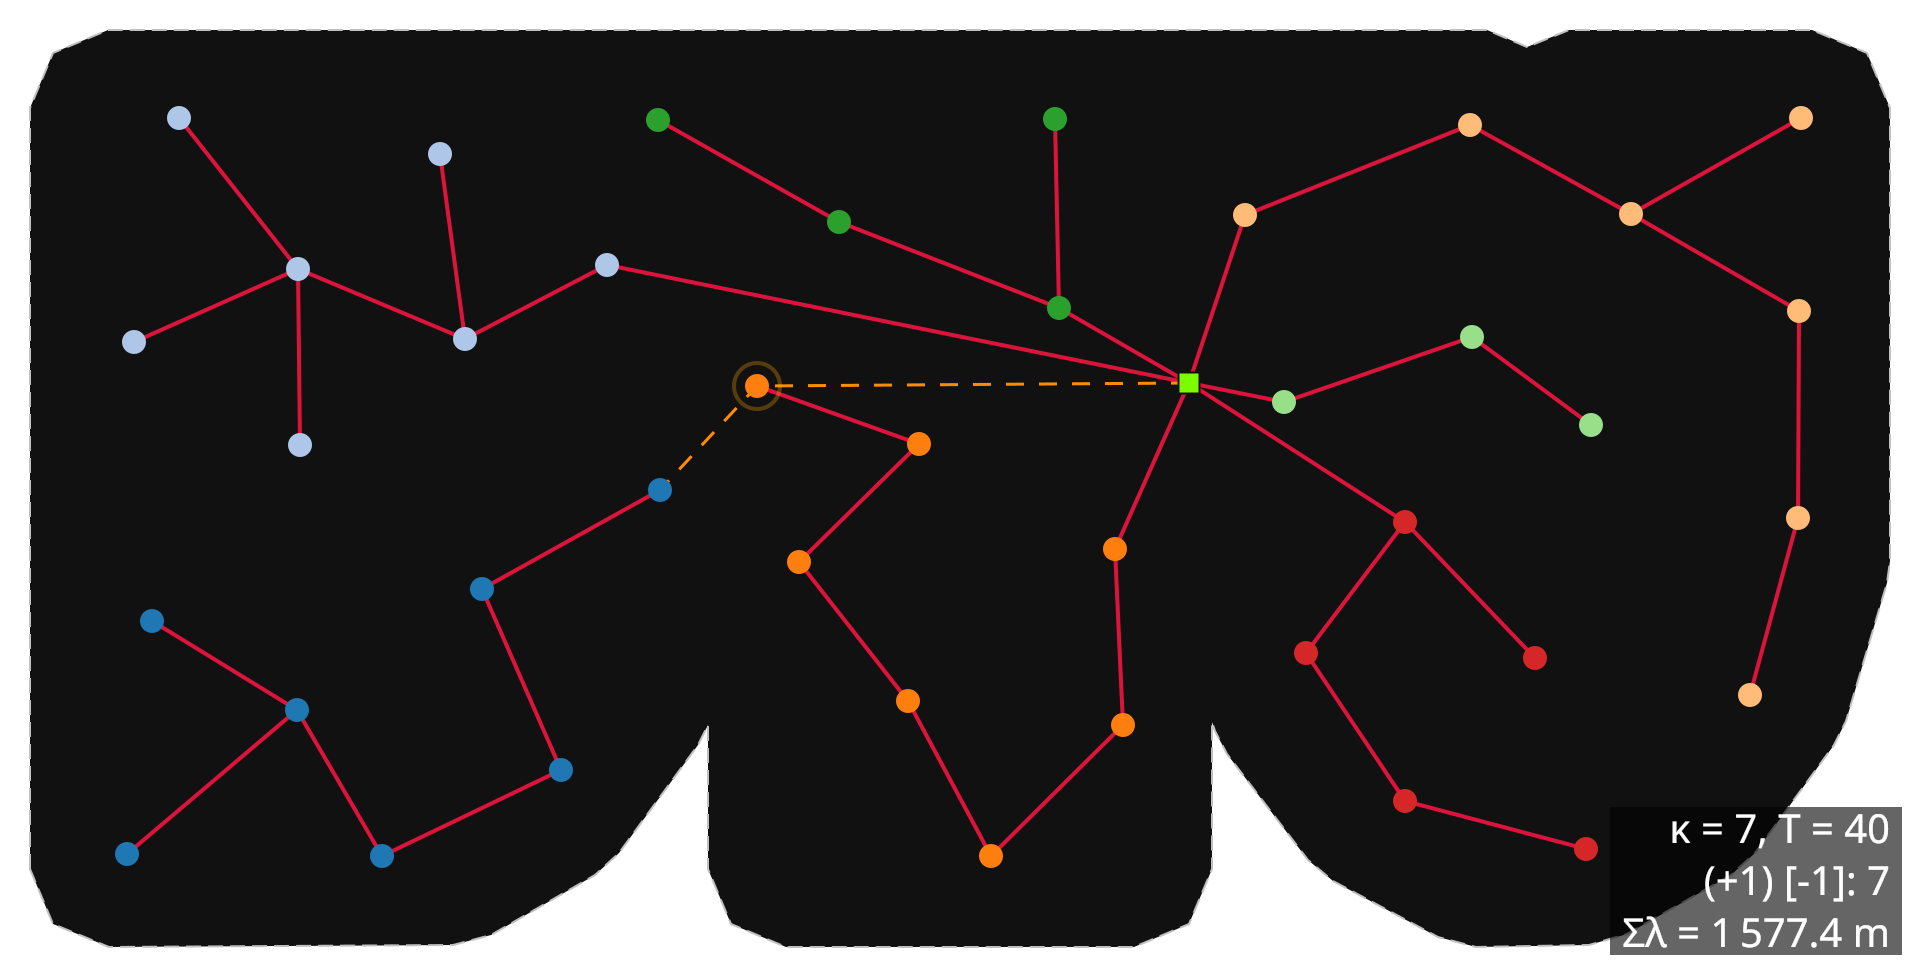

In [25]:
wfn5.optimize()
wfn5

In [26]:
wfn5.solution_info()

{'router': 'EWRouter', 'capacity': 7, 'method': 'biased_EW', 'iterations': 35}

#### Turbines outside the border or inside the obstacles

When [wfn.optimize()](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.optimize) is called, it first checks that all turbines are within the allowed area and not inside any exclusion zone. A `ValueError` is raised otherwise. Turbines on a border or obstacle boundary pass this check; substations are not checked.

In [27]:
turbinesC = np.array([
    [0, 0], [316976, 6175410], [316998, 6175380],
])  # fmt: skip

# borderC and obstaclesC_ are reused from the cell above
substationsC = np.array([[317167, 6175351]])

In [28]:
wfn6 = WindFarmNetwork(
    turbinesC=turbinesC,
    substationsC=substationsC,
    borderC=borderC,
    obstacleC_=obstaclesC_,
    cables=7,
)

In [29]:
try:
    wfn6.optimize()
except ValueError as e:
    print('Caught expected exception:', e)

Caught expected exception: Turbine out of bounds!
